In [66]:
import pandas as pd

In [67]:
df = pd.read_csv('taxi.csv')

In [68]:
df.shape

(209673, 8)

In [69]:
df = df.drop_duplicates()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205348 entries, 0 to 209672
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_duration       205348 non-null  float64
 1   distance_traveled   205348 non-null  float64
 2   num_of_passengers   205348 non-null  float64
 3   fare                205348 non-null  float64
 4   tip                 205348 non-null  int64  
 5   miscellaneous_fees  205348 non-null  float64
 6   total_fare          205348 non-null  float64
 7   surge_applied       205348 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 14.1 MB


In [71]:
df.head()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,748.0,2.75,1.0,75.00,24,6.300,105.300,0
1,1187.0,3.43,1.0,105.00,24,13.200,142.200,0
2,730.0,3.12,1.0,71.25,0,26.625,97.875,1
3,671.0,5.63,3.0,90.00,0,9.750,99.750,0
4,329.0,2.09,1.0,45.00,12,13.200,70.200,0


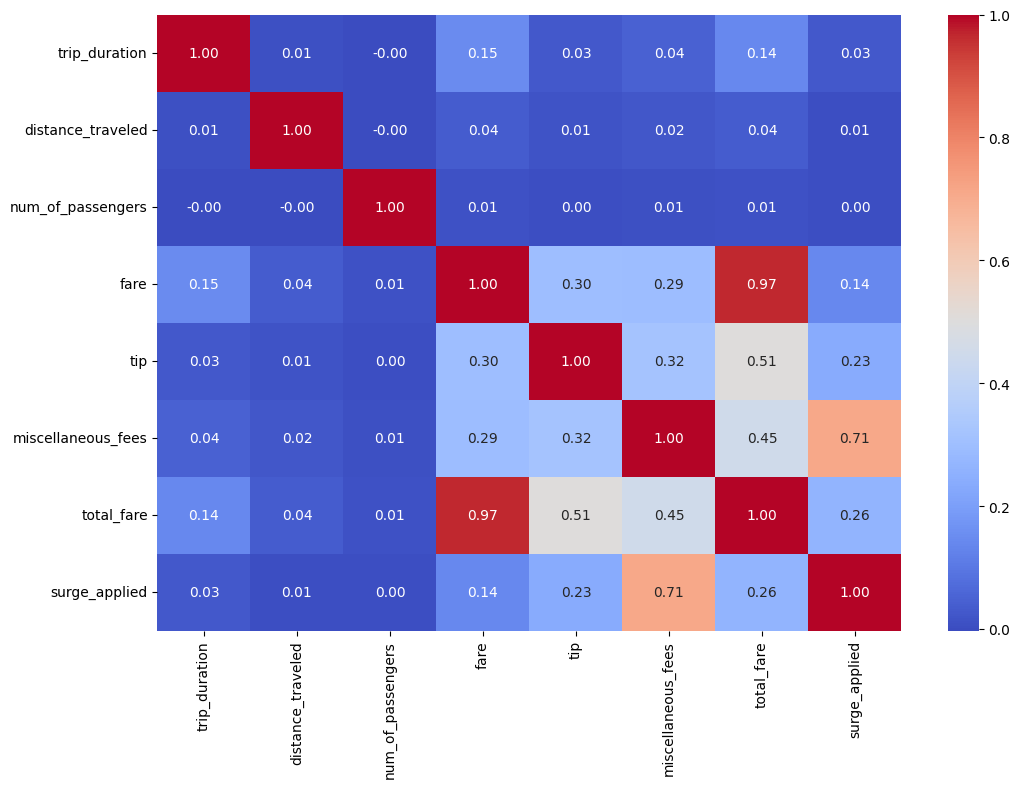

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm', fmt='.2f')
plt.show()

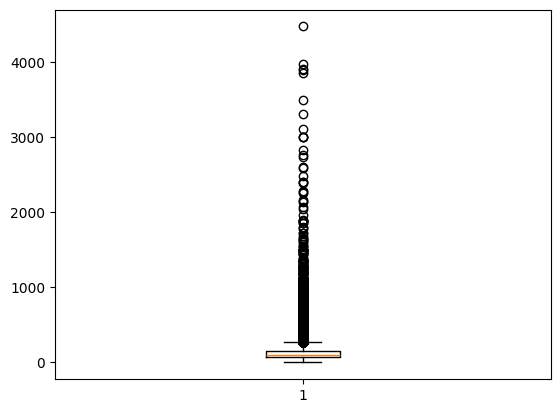

In [73]:
plt.boxplot(df['total_fare'])
plt.show()

In [74]:
df.describe()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
count,205348.000000,205348.000000,205348.000000,205348.000000,205348.000000,205348.000000,205348.000000,205348.000000
mean,1189.102226,5.123167,1.298654,100.656568,13.247560,15.294384,129.198512,0.285803
std,4824.302160,126.528223,0.939258,86.142902,20.507879,12.621609,99.283531,0.451797
min,0.000000,0.020000,0.000000,0.000000,0.000000,-0.500000,0.000000,0.000000
25%,454.000000,1.980000,1.000000,52.500000,0.000000,6.000000,73.125000,0.000000
50%,716.000000,3.250000,1.000000,78.750000,9.000000,9.750000,103.500000,0.000000
75%,1110.000000,5.810000,1.000000,116.250000,20.000000,26.525000,153.450000,1.000000
max,86387.000000,57283.910000,9.000000,4466.250000,2500.000000,435.000000,4472.250000,1.000000


In [75]:
df.shape

(205348, 8)

In [76]:
df = df[(df['miscellaneous_fees'] > 0)]
df = df[(df['trip_duration'] > 0)]
df = df[(df['num_of_passengers'] > 0)]
df = df[(df['fare'] > 0)]

In [77]:
df.shape

(204277, 8)

In [78]:
df.describe()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
count,204277.000000,204277.000000,204277.000000,204277.000000,204277.000000,204277.000000,204277.000000,204277.000000
mean,1190.133613,5.120631,1.303563,100.670072,13.247556,15.307313,129.224942,0.285901
std,4835.050612,126.857867,0.938224,85.985880,20.476603,12.608695,99.120054,0.451844
min,1.000000,0.020000,1.000000,0.075000,0.000000,0.075000,2.325000,0.000000
25%,454.000000,2.000000,1.000000,52.500000,0.000000,6.000000,73.125000,0.000000
50%,717.000000,3.250000,1.000000,78.750000,9.000000,9.750000,103.500000,0.000000
75%,1110.000000,5.810000,1.000000,116.250000,20.000000,26.525000,153.450000,1.000000
max,86387.000000,57283.910000,9.000000,4466.250000,2500.000000,435.000000,4472.250000,1.000000


In [79]:
print((df == 0).sum())

trip_duration              0
distance_traveled          0
num_of_passengers          0
fare                       0
tip                    89418
miscellaneous_fees         0
total_fare                 0
surge_applied         145874
dtype: int64


In [80]:
X = df.drop('total_fare', axis=1)
y = df['total_fare']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
X_train.head()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,surge_applied
140687,881.0,6.21,1.0,105.00,0,9.75,0
32966,149.0,1.38,1.0,112.50,0,2.25,0
21075,245.0,1.22,1.0,37.50,9,10.20,0
118760,2448.0,11.23,1.0,206.25,0,6.00,0
3354,343.0,1.56,1.0,45.00,14,26.95,1


In [83]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scale, y_train)

y_pred_test = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('mse Train', mean_squared_error(y_train, y_pred_train))
print('rmse Train', root_mean_squared_error(y_train, y_pred_train))
print('r2 train', r2_score(y_train, y_pred_train))

print("-"*30)
print('mse Test', mean_squared_error(y_test, y_pred_test))
print('rmse Test', root_mean_squared_error(y_test, y_pred_test))

print('r2 test', r2_score(y_test, y_pred_test))

mse Train 9.139223155452089e-27
rmse Train 9.559928428315815e-14
r2 train 1.0
------------------------------
mse Test 8.554397277992241e-27
rmse Test 9.248998474425348e-14
r2 test 1.0


In [85]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.2)
lasso.fit(X_train_scale, y_train)

y_pred_test = lasso.predict(X_test_scale)
y_pred_train = lasso.predict(X_train_scale)

print('mse Train', mean_squared_error(y_train, y_pred_train))
print('rmse Train', root_mean_squared_error(y_train, y_pred_train))
print('r2 train', r2_score(y_train, y_pred_train))

print("-"*30)
print('mse Test', mean_squared_error(y_test, y_pred_test))
print('rmse Test', root_mean_squared_error(y_test, y_pred_test))

print('r2 test', r2_score(y_test, y_pred_test))

mse Train 2.7175249951686555
rmse Train 1.648491733424422
r2 train 0.9997259994030075
------------------------------
mse Test 2.6679266184873427
rmse Test 1.6333788961803513
r2 test 0.9997177343497938


In [93]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=2)
ridge.fit(X_train_scale, y_train)

y_pred_test = ridge.predict(X_test_scale)
y_pred_train = ridge.predict(X_train_scale)

print('mse Train', mean_squared_error(y_train, y_pred_train))
print('rmse Train', root_mean_squared_error(y_train, y_pred_train))
print('r2 train', r2_score(y_train, y_pred_train))

print("-"*30)
print('mse Test', mean_squared_error(y_test, y_pred_test))
print('rmse Test', root_mean_squared_error(y_test, y_pred_test))

print('r2 test', r2_score(y_test, y_pred_test))

mse Train 1.180518866762443e-06
rmse Train 0.0010865168506573853
r2 train 0.9999999998809715
------------------------------
mse Test 1.0872864939726327e-06
rmse Test 0.0010427303074010234
r2 test 0.9999999998849655


In [94]:
from xgboost import XGBRegressor

xg = XGBRegressor(n_estimators=201, max_depth=3, learning_rate=0.03, random_state=42)
xg.fit(X_train_scale, y_train)

y_pred_test = xg.predict(X_test_scale)

y_pred_train = xg.predict(X_train_scale)
print('mse Train', mean_squared_error(y_train, y_pred_train))
print('rmse Train', root_mean_squared_error(y_train, y_pred_train))
print('r2 train', r2_score(y_train, y_pred_train))

print("-"*30)
print('mse Test', mean_squared_error(y_test, y_pred_test))
print('rmse Test', root_mean_squared_error(y_test, y_pred_test))
print('r2 test', r2_score(y_test, y_pred_test))


mse Train 745.1970934925417
rmse Train 27.298298362581903
r2 train 0.924863819520716
------------------------------
mse Test 500.79955138970195
rmse Test 22.37855114590089
r2 test 0.9470155925517535


In [ ]:
# zero values
# outliers